<a href="https://colab.research.google.com/github/JingYang06522/DSTest/blob/main/trainmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("malaysia_house_price_data_2025_cleaned.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (2318, 8)


In [ ]:
X = df[['Area', 'State', 'Tenure', 'Type', 'Median_PSF', 'Transactions']]
y = df['Median_Price']

print("Features (X):", X.columns.tolist())
print("Target   (y):", y.name)
print()
print("X shape:", X.shape)
print("y shape:", y.shape)

Features (X): ['Area', 'State', 'Tenure', 'Type', 'Median_PSF', 'Transactions']
Target   (y): Median_Price

X shape: (2318, 6)
y shape: (2318,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print()
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1854, 6)
y_train: (1854,)

X_test: (464, 6)
y_test: (464,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['Area', 'State', 'Tenure', 'Type']

numerical_features = ['Median_PSF', 'Transactions']

preprocessor = ColumnTransformer(
    transformers=[('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
                  ('numerical', 'passthrough', numerical_features)]
)

print("Preprocessor created")
print("Categorical features:", categorical_features)
print("Numerical features  :", numerical_features)

Preprocessor created
Categorical features: ['Area', 'State', 'Tenure', 'Type']
Numerical features  : ['Median_PSF', 'Transactions']


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original  X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)
print()
print("Original  X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original  X_train shape: (1854, 6)
Processed X_train shape: (1854, 314)

Original  X_test shape: (464, 6)
Processed X_test shape: (464, 314)


In [ ]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
import numpy as np

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)
y_pred_linear = linear_model.predict(X_test_processed)

print("Linear Regression training completed.")
print("Number of predictions:", len(y_pred_linear))

Linear Regression training completed.
Number of predictions: 464


In [ ]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test,y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("====================================")
print("Linear Regression Results")
print("====================================")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)
print("====================================")

Linear Regression Results
MAE : 119355.80111310784
MSE : 29619030425.34827
RMSE: 172101.80250464627
R²  : 0.7469806942316024


In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_split=10, min_samples_leaf=5)
tree_model.fit(X_train_processed, y_train)
y_pred_tree = tree_model.predict(X_test_processed)

print("Decision Tree Regression training completed.")
print("Number of predictions:", len(y_pred_tree))

Decision Tree Regression training completed.
Number of predictions: 464


In [ ]:
mae_tree = mean_absolute_error(y_test,y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("====================================")
print("Decision Tree Results")
print("====================================")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)
print("====================================")

Decision Tree Results
MAE : 110004.93246709052
MSE : 30290842195.685734
RMSE: 174042.6447618104
R²  : 0.7412417707997148


In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)


y_pred_rf = random_forest_model.predict(
    X_test_processed
)

print("Random Forest Regression training completed.")
print("Number of predictions:", len(y_pred_rf))

Random Forest Regression training completed.
Number of predictions: 464


In [ ]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)
print("====================================")
print("Random Forest Results")
print("====================================")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)
print("====================================")

Random Forest Results
MAE : 100099.38071471968
MSE : 23165156582.186115
RMSE: 152201.040016769
R²  : 0.8021126366302371


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    loss='squared_error'
)

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

y_pred_gb = gradient_boosting_model.predict(
    X_test_processed
)

print("Gradient Boosting Regression training completed.")
print("Number of predictions:", len(y_pred_gb))

Gradient Boosting Regression training completed.
Number of predictions: 464


In [ ]:
mae_gb = mean_absolute_error(
    y_test,
    y_pred_gb
)

mse_gb = mean_squared_error(
    y_test,
    y_pred_gb
)

rmse_gb = np.sqrt(mse_gb)

r2_gb = r2_score(
    y_test,
    y_pred_gb
)
print("====================================")
print("Gradient Boosting Results")
print("====================================")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)
print("====================================")

Gradient Boosting Results
MAE : 100788.76129446774
MSE : 23110006088.419773
RMSE: 152019.75558597565
R²  : 0.8025837573740682


In [ ]:
y_train_pred_rf = random_forest_model.predict(X_train_processed)

train_r2_rf = r2_score(y_train, y_train_pred_rf)

test_r2_rf = r2_score(y_test, y_pred_rf)

print("====================================")
print("Random Forest R² Comparison")
print("====================================")
print("Training R²:", train_r2_rf)
print("Testing R² :", test_r2_rf)
print("Difference :", train_r2_rf - test_r2_rf)
print("====================================")

Random Forest R² Comparison
Training R²: 0.9047678556656995
Testing R² : 0.8021126366302371
Difference : 0.10265521903546238


In [ ]:
tuned_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

tuned_rf_model.fit(X_train_processed, y_train)

y_pred_tuned_rf = tuned_rf_model.predict(X_test_processed)

print("Tuned Random Forest training completed.")

Tuned Random Forest training completed.


In [ ]:
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mse_tuned_rf)
r2_tuned_rf = r2_score(y_test,y_pred_tuned_rf)

print("====================================")
print("Tuned Random Forest Results")
print("====================================")
print("MAE :", mae_tuned_rf)
print("MSE :", mse_tuned_rf)
print("RMSE:", rmse_tuned_rf)
print("R²  :", r2_tuned_rf)
print("====================================")

Tuned Random Forest Results
MAE : 103227.99142353839
MSE : 23771190801.42632
RMSE: 154179.08678360473
R²  : 0.7969356151267641


In [ ]:
y_train_pred_tuned_rf = tuned_rf_model.predict(X_train_processed)
train_r2_tuned_rf = r2_score(y_train, y_train_pred_tuned_rf)

print("Training R²:", train_r2_tuned_rf)
print("Testing R² :", r2_tuned_rf)
print("Difference :", train_r2_tuned_rf - r2_tuned_rf)

Training R²: 0.8224793655930689
Testing R² : 0.7969356151267641
Difference : 0.02554375046630475


In [ ]:
feature_names = preprocessor.get_feature_names_out()

importance_values = random_forest_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 20 Most Important Features:")
display(feature_importance.head(20))

Top 20 Most Important Features:


,Feature,Importance
312,numerical__Median_PSF,0.629735
304,categorical__Type_BUNGALOW,0.096385
313,numerical__Transactions,0.044427
303,categorical__Type_APARTMENT,0.031936
307,categorical__Type_FLAT,0.029911
309,categorical__Type_SERVICE RESIDENCE,0.028363
308,categorical__Type_SEMI D,0.027359
310,categorical__Type_TERRACE HOUSE,0.013624
190,categorical__Area_PETALING JAYA,0.012680
306,categorical__Type_CONDOMINIUM,0.009999


In [ ]:
prediction_results = pd.DataFrame({
    'Actual_Price': y_test.values,
    'Predicted_Price': y_pred_rf
})

prediction_results['Error'] = (
    prediction_results['Actual_Price']
    - prediction_results['Predicted_Price']
)

prediction_results['Absolute_Error'] = (
    prediction_results['Error'].abs()
)

print("Prediction Results:")
display(prediction_results.head(10))

print("Average Error:",
      prediction_results['Error'].mean())

print("Average Absolute Error:",
      prediction_results['Absolute_Error'].mean())

print("Largest Absolute Error:",
      prediction_results['Absolute_Error'].max())

Prediction Results:


,Actual_Price,Predicted_Price,Error,Absolute_Error
0,234000.0,3.562868e+05,-122286.840943,122286.840943
1,1526237.5,1.070421e+06,455816.864415,455816.864415
2,839000.0,1.081754e+06,-242753.988877,242753.988877
3,235000.0,2.670180e+05,-32017.982380,32017.982380
4,115000.0,1.761207e+05,-61120.743386,61120.743386
5,293000.0,3.851345e+05,-92134.453699,92134.453699
6,262500.0,2.886164e+05,-26116.373982,26116.373982
7,950000.0,4.083799e+05,541620.108032,541620.108032
8,1260000.0,1.102523e+06,157477.070862,157477.070862
9,260000.0,2.685450e+05,-8545.012142,8545.012142


Average Error: 900.5085595254023
Average Absolute Error: 100099.38071471968
Largest Absolute Error: 670193.4315009392


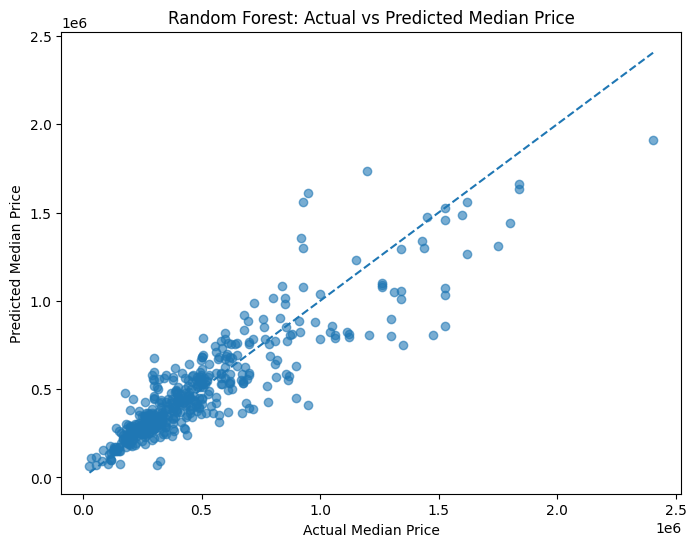

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

# Perfect prediction line
min_price = min(y_test.min(), y_pred_rf.min())
max_price = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel("Actual Median Price")
plt.ylabel("Predicted Median Price")
plt.title("Random Forest: Actual vs Predicted Median Price")

plt.show()

In [ ]:
import joblib

model_bundle = {
    'preprocessor': preprocessor,
    'models': {
        'Linear Regression': linear_model,
        'Decision Tree': tree_model,
        'Random Forest': random_forest_model,
        'Gradient Boosting': gradient_boosting_model
    },
    'metrics': {
        'Linear Regression': {
            'MAE': mae_linear,
            'MSE': mse_linear,
            'RMSE': rmse_linear,
            'R2': r2_linear
        },
        'Decision Tree': {
            'MAE': mae_tree,
            'MSE': mse_tree,
            'RMSE': rmse_tree,
            'R2': r2_tree
        },
        'Random Forest': {
            'MAE': mae_rf,
            'MSE': mse_rf,
            'RMSE': rmse_rf,
            'R2': r2_rf
        },
        'Gradient Boosting': {
            'MAE': mae_gb,
            'MSE': mse_gb,
            'RMSE': rmse_gb,
            'R2': r2_gb
        }
    }
}
joblib.dump(
    model_bundle,
    'malaysia_house_price_models.joblib'
)

print("====================================")
print("ALL MODELS SAVED SUCCESSFULLY")
print("====================================")
print("File: malaysia_house_price_models.joblib")
print("Models saved:")

for model_name in model_bundle['models']:
    print("-", model_name)

ALL MODELS SAVED SUCCESSFULLY
File: malaysia_house_price_models.joblib
Models saved:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [ ]:
loaded_bundle = joblib.load('malaysia_house_price_models.joblib')

print("Model bundle loaded successfully!")
print("\nAvailable models:")
for model_name in loaded_bundle['models']:
    print("-", model_name)

print("\nStored metrics:")
print(pd.DataFrame(loaded_bundle['metrics']).T)


Model bundle loaded successfully!

Available models:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Stored metrics:
                             MAE           MSE           RMSE        R2
Linear Regression  119355.801113  2.961903e+10  172101.802505  0.746981
Decision Tree      110004.932467  3.029084e+10  174042.644762  0.741242
Random Forest      100099.380715  2.316516e+10  152201.040017  0.802113
Gradient Boosting  100788.761294  2.311001e+10  152019.755586  0.802584
